import numpy as np
import pandas as pd


In [209]:
import numpy as np
import pandas as pd

In [210]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [211]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2014,ham,Ambrith..madurai..met u in arun dha marrge..re...,NaN,NaN,NaN
3416,ham,But i haf enuff space got like 4 mb...,NaN,NaN,NaN
4813,ham,Ummmmmaah Many many happy returns of d day my ...,NaN,NaN,NaN
2134,ham,If he started searching he will get job in few...,NaN,NaN,NaN
3784,ham,Let me know if you need anything else. Salad o...,NaN,NaN,NaN


In [212]:
df.shape

(5572, 5)

In [213]:
#we follow the below steps to build our model
#1. Data cleaning
#2. EDA
#3. Text Preprocessing
#4. Model Building
#5. Evaluation
#6. Improvement
#7. Website
# Deployment

In [214]:
#above we see that the 3 unnamed columns have very less amount of data like, 50, 12, 6 non null values so we can drop those columns
#drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [215]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4886,spam,Todays Vodafone numbers ending with 4882 are s...,NaN,NaN,NaN
4936,ham,G wants to know where the fuck you are,NaN,NaN,NaN
2965,ham,"Are you being good, baby? :)",NaN,NaN,NaN
4035,ham,How are you holding up?,NaN,NaN,NaN
5055,ham,Goodnight da thangam I really miss u dear.,NaN,NaN,NaN


In [216]:
#rename the columns so that we can understand it better
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
1330,ham,"Aight no rush, I'll ask jay",NaN,NaN,NaN
1969,spam,You have won a guaranteed å£200 award or even ...,NaN,NaN,NaN
3083,ham,Ok lor. I ned 2 go toa payoh 4 a while 2 retur...,NaN,NaN,NaN
2350,ham,You will be in the place of that man,NaN,NaN,NaN
3175,ham,Havent still waitin as usual... ÌÏ come back s...,NaN,NaN,NaN


In [217]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [218]:
#Ml mode l can only understand the numerical values but our #target column have categorical values ham and spam so we #need to convert those categorical values into numerical #values ham =0 and spam =1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [219]:
#head is used to see the top 5 rows of the dataframe in pandas
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [220]:
#check missing values in the dataset
df.isnull().sum()
#there are no missing values in the dataset

target           0
text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [221]:
#chekc duplicated values in the dataset
df.duplicated().sum()
#there are 0 duplicated values in the dataset so we have successfully removed the duplicated values

np.int64(403)

In [222]:
#remove duplicated values
#keep = first means we will keep the first occurrence of the duplicated value and drop the rest
df = df.drop_duplicates(keep='first')

In [223]:
#again check duplicated values in the dataset
df.duplicated().sum()

np.int64(0)

In [224]:
#after removing duplicated values we have total 5169 rows and 2 columns in the dataset
df.shape

(5169, 5)

2.EDA

In [225]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [226]:
#check how many ham and spam messages are there in the #dataset
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

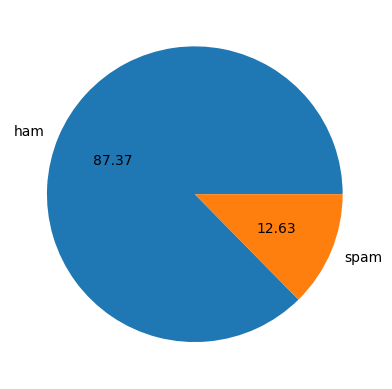

In [227]:
#visualization of ham and spam messages using pie chart
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()
#data is imbalanced because we have more ham messages than spam messages in the dataset

In [228]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [229]:
#we create 3 columns in the dataset for deeper analysis of the text data
#1. num_characters: number of characters in the text message
#2. num_words: number of words in the text message
#3. num_sentences: number of sentences in the text message
#to do this we need nltk library
#nltk is a natural language processing library in python which is used for text preprocessing and analysis
import nltk
#punkt is a pre-trained model in nltk which is used for tokenization of sentences and words
#we need to download the punkt model to load data into our model
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [230]:
#count number of characters in the text message in text column and store it in num_characters column
df['num_characters'] = df['text'].apply(len)

In [231]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61


In [232]:
#tokenize the text message into numbers and then count the number of words in the text message and store it in num_words column

#count number of words in the text message in text column and store it in num_words column

#nltk.word_tokenize is used to tokenize the text message into words and then we count the number of words in the text message

#lambda is an anonymous function in python which is used to create a function without a name

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [233]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15


In [234]:
#tokenize the text message into sentences and then count the number of sentences in the text message and store it in num_sentences column

#sent-tokenize is used to tokenize the text message into sentences and then we count the number of sentences in the text message
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [235]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1


In [236]:
#here describe is used to get the statistical summary of the numerical columns in the dataset
#here maximum number of characters in the text message is 910 and 
# minimum number of characters in the text message is 2 and 
# average number of characters in the text message is 71.48
#maximum number of words in the text message is 152 and
# minimum number of words in the text message is 1 and
# average number of words in the text message is 13.05
#maximum number of sentences in the text message is 10 and
# minimum number of sentences in the text message is 1 and
# average number of sentences in the text message is 1.75
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [237]:
#here we will do the same analysis for ham messages only
#0 means ham messages and 1 means spam messages in the target column
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()   

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [238]:
#here we will do the same analysis for spam messages only
#0 means ham messages and 1 means spam messages in the target column
#minimum number of characters in the text message is 2 and
# average number of characters in the text message is 138.67 and
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()   

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [239]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='num_characters', ylabel='Count'>

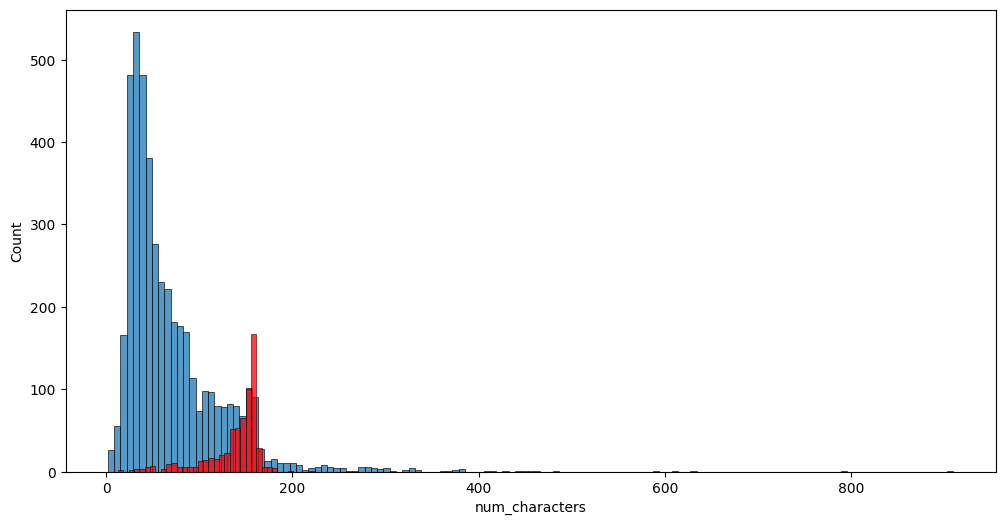

In [240]:
#we import seaborn library for data visualization
# we draw a histogram of num_characters column for ham and spam messages
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters']
,color='red')

<Axes: xlabel='num_words', ylabel='Count'>

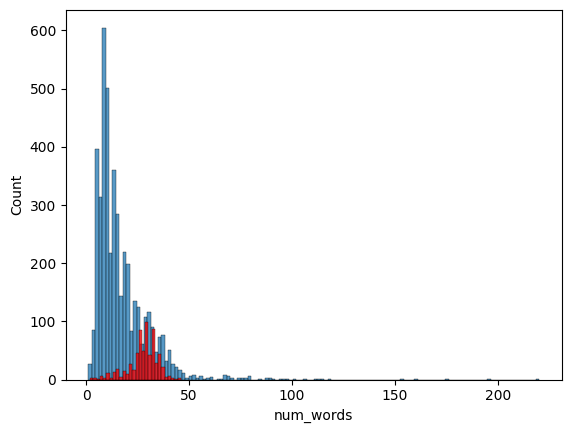

In [241]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words']
,color='red')

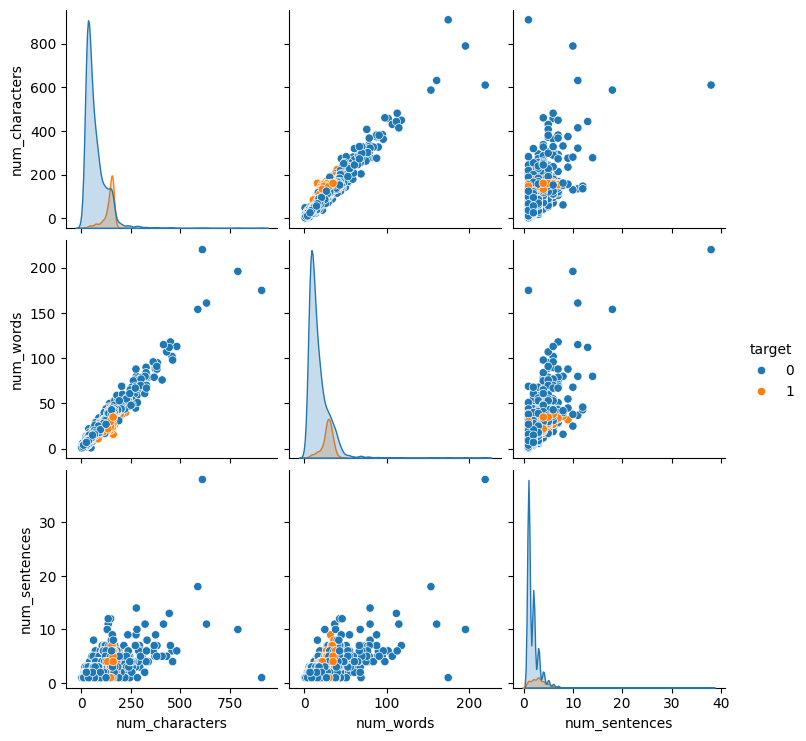

In [242]:
#now we can we can see  the relationship between num_characters, num_words and num_sentences columns with the target column using pairplot
sns.pairplot(df,hue='target')

<Axes: >

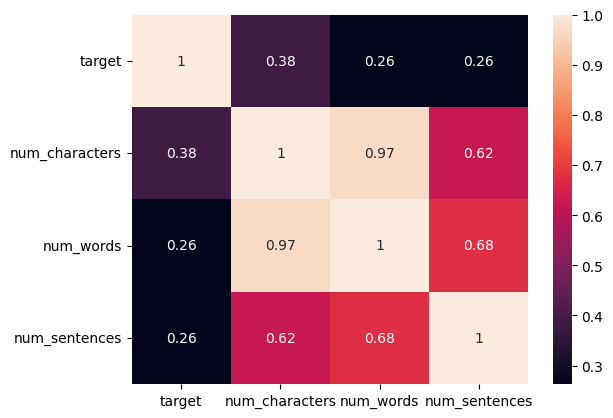

In [243]:
#heatmap is used to see the correlation between the numerical columns in the dataset
# corelation between target and num_characters is 0.38 which means there is a strong positive correlation between target and num_characters columns

#target vs num_characters (0.38): এখানে সম্পর্ক সবচেয়ে বেশি (০.৩৮)। এর মানে হলো, একটি মেসেজে কতগুলো অক্ষর আছে, তা দেখে স্প্যাম চেনার সম্ভাবনা সবচেয়ে বেশি।

#target vs num_words (0.26): এটিও গুরুত্বপূর্ণ, তবে ক্যারেক্টারের তুলনায় কিছুটা কম।

#target vs num_sentences (0.26): এটিও একই রকম প্রভাব ফেলে।
#এই চার্ট থেকে আমরা ৩টি সিদ্ধান্ত নিতে পারি:
#স্প্যাম মেসেজ সাধারণত বড় হয়: যেহেতু target এর সাথে num_characters এর একটি পজিটিভ সম্পর্ক আছে, তাই আমরা বলতে পারি মেসেজ যত বড় হবে, সেটি স্প্যাম হওয়ার সম্ভাবনা তত বাড়বে।

#কলাম বাছাই (Feature Selection): আপনার মডেল ট্রেইন করার সময় আপনি যদি শুধু একটি কলাম নিতে চান, তবে num_characters নেওয়া সবচেয়ে বুদ্ধিমানের কাজ হবে, কারণ এর কো-রিলেশন সবচেয়ে বেশি।

#অতিরিক্ত ডাটা: যেহেতু ক্যারেক্টার, শব্দ এবং বাক্য—এই তিনটিই একে অপরের সাথে খুব গভীরভাবে যুক্ত (০.৯৭), তাই তিনটিকে একসাথে মডেলে ব্যবহার করলে Multicollinearity সমস্যা হতে পারে। প্রোফেশনালরা সাধারণত এখান থেকে শুধু সেরা একটিকে বেছে নেন।

#so we choose num_characters column for our model building because it has the highest correlation with the target column
sns.heatmap(df.corr(numeric_only=True), annot=True)

3.Data preprocessing or Text preprocessing 

 

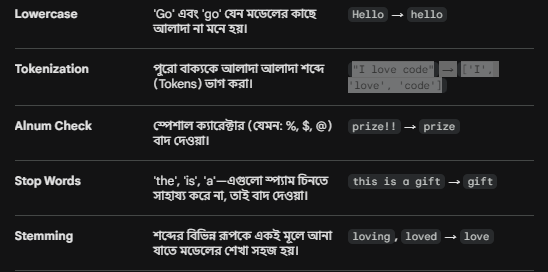


#lowercase
#Tokenization
#Removing special characters
#Removing stop words and punctuation     
#Stemming

In [244]:
#all stop words in the english language
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

# স্টপ-ওয়ার্ড লিস্টটি একবার লোড করে সেট (Set) হিসেবে রাখুন
# সেট ব্যবহার করলে খোঁজার গতি অনেক বেড়ে যায়
stop_words = set(stopwords.words('english'))
#word_tokenize is function of ntlk library which is used to tokenize the text message into words
#here y[]is a list which is used to store the alphanumeric words in the text message
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

 # removing special characters and alphanumeric characters from the text message 
 
    y = []
    for i in text:
        if i.isalnum():
            y.append(i) 
    
    # clone the list in text variable and clear the y list to remove all the stop words and punctuation from the text message
    text = y[:]
    y.clear()

    #removing stop words and punctuation from the text message
    for i in  text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    
    #removing stemming from the text message
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))    
    
    return " ".join(y)
transform_text('Did you liked my presentation? It was awesome!!!')

'like present awesom'

In [245]:
#all stop words in the english language
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [246]:
#punctuation marks in the english language
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [247]:
#stemming is the process of reducing a word to its root word
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')
ps.stem('liked')

'like'

In [248]:
# apply the transform_text function to the text column in the dataset and store it in a new column called transformed_text
df['transformed_text'] = df['text'].apply(transform_text)

In [249]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1,nah think goe usf live around though


In [250]:
# ১. Unnamed কলামগুলো মুছে ফেলা
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

# ২. চেক করে দেখুন কলামগুলো গেছে কি না
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [251]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [252]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')


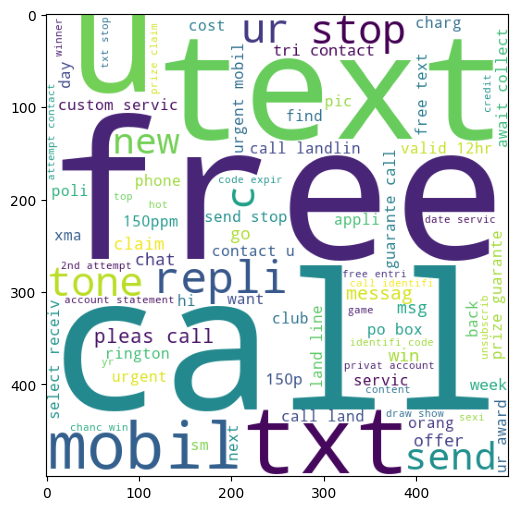

In [253]:
#what we do here?
#generate a word cloud for ham messages and spam messages separately to see the most common words in ham and spam messages
#and the Big words are the most common words in ham and spam messages

spam_wc= wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" )"))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

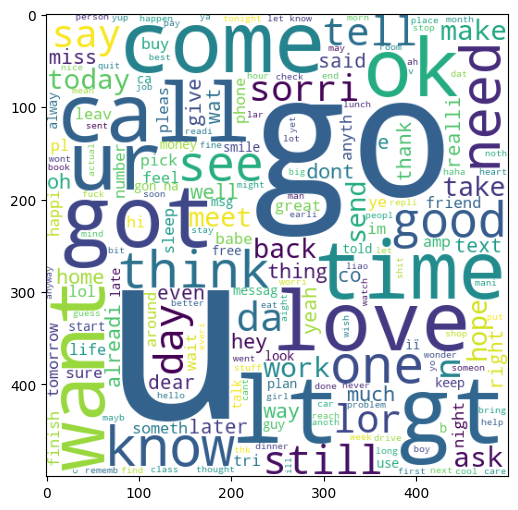

In [254]:
ham_wc= wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [255]:
df.head()


,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [256]:
# see top 30 words in ham messages and spam messages using countplot
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)    

In [257]:
len(spam_corpus)

9939

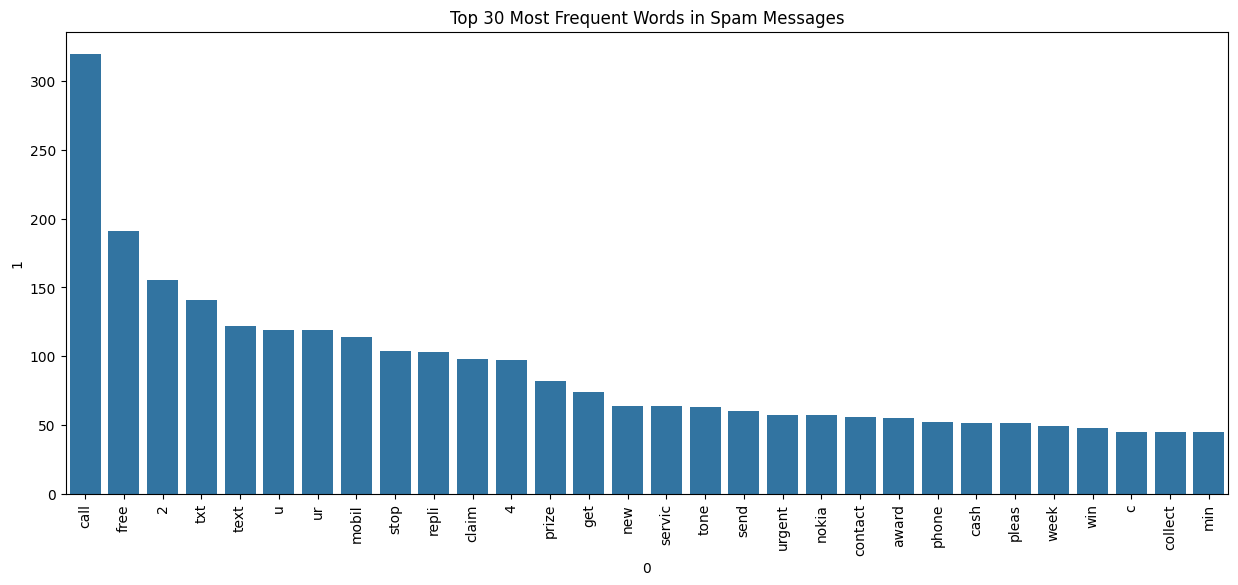

In [258]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ১. স্প্যাম কর্পাস থেকে সবচেয়ে বেশি আসা ৩০টি শব্দ এবং তাদের সংখ্যা দিয়ে একটি ডাটাফ্রেম তৈরি করা
# Counter(...).most_common(30) সরাসরি একটি লিস্ট দেয়, যা পাণ্ডাস সহজেই পড়তে পারে
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

# ২. বারপ্লট তৈরি করা
plt.figure(figsize=(15,6))
sns.barplot(x=most_common_df[0], y=most_common_df[1])

# ৩. নামগুলো যাতে একটার ওপর আরেকটা না পড়ে, তাই ভার্টিক্যাল (Vertical) করে দেওয়া
plt.xticks(rotation='vertical')
plt.title('Top 30 Most Frequent Words in Spam Messages')
plt.show()

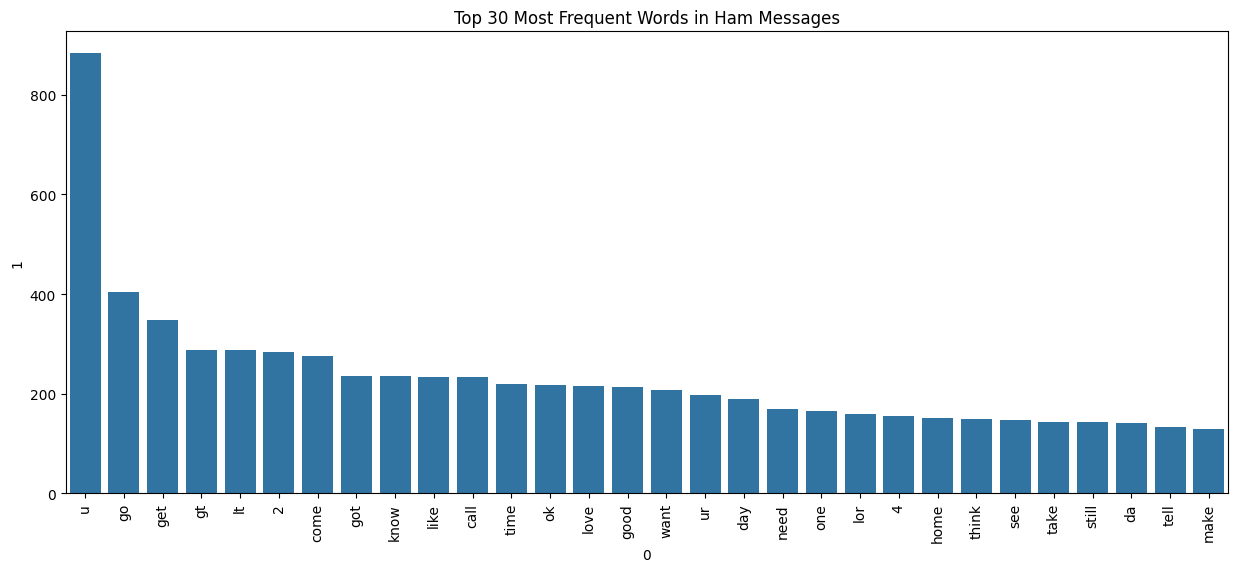

In [259]:
#Top 30 most common words in ham messages
# see top 30 words in ham messages and spam messages using countplot
# ১. হ্যাম মেসেজের সব শব্দগুলো একটি লিস্টে (ham_corpus) জমা করা
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

# ২. সবচেয়ে বেশি আসা ৩০টি শব্দ নিয়ে ডেটাফ্রেম তৈরি করা
from collections import Counter
most_common_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))

# ৩. বার-প্লট তৈরি করা
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.barplot(x=most_common_ham[0], y=most_common_ham[1])

# ৪. এক্স-অক্ষের লেখাগুলো ভার্টিক্যাল করে দেওয়া
plt.xticks(rotation='vertical')
plt.title('Top 30 Most Frequent Words in Ham Messages')
plt.show()

In [260]:
len(ham_corpus)

35404

4.Model Building

In [261]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()


In [303]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [263]:
X.shape

(5169, 3000)

In [264]:
y = df['target'].values

In [265]:
from sklearn.model_selection import train_test_split

In [266]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [267]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score 

In [268]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [269]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [270]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [271]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


tfidf-->MNB

In [272]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [273]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [274]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [275]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [276]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [277]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [278]:
# ১. প্রথমে খালি লিস্ট দুটি তৈরি করুন
accuracy_scores = []
precision_scores = []

# ২. এখন লুপটি চালিয়ে ডাটা অ্যাপেন্ড করুন
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9332688588007737
Precision -  0.8415841584158416
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96


c:\Users\Sadman\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Sadman\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [279]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.933269,0.841584


In [280]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [281]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.933269


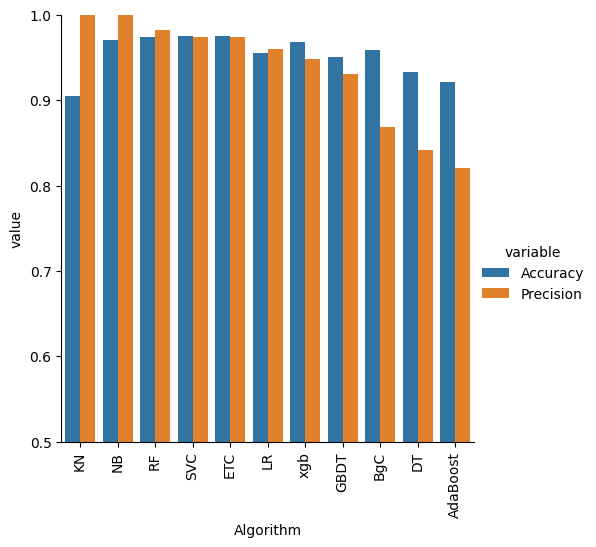

In [282]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

Model Improving

# model improve
# 1. Change the max_features parameter of TfIdf

In [283]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [284]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [285]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [286]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [287]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [288]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
6,xgb,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718
7,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,DT,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584


In [289]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [290]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [291]:
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [292]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


In [293]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [294]:
from sklearn.ensemble import StackingClassifier

In [295]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [296]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9465648854961832


In [297]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
# নিশ্চিত করুন যে আপনি X_train এবং y_train দিয়ে fit করেছেন
mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [304]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))